In [153]:
import sys
sys.path.append("/home/tg8455/srths/downloaded_code")
from BBSims import noise_calc
import pymaster as nmt
import healpy as hp
import numpy as np

from typing import List, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from itertools import combinations_with_replacement as cwr
from copy import deepcopy
import astropy.units as u

note: this notebook will only be used to make + load our mock, noise-only data; for messiness, figures, and justification for the ell-ranges that we want to use, consult a parallel version of this notebook;

### Raison d'etre: generate one iso_mode at a time, from the 12 possible versions (4 modes x 3 possibilities of R-I correlation)

In [3]:
### science functions:
def make_isocur_params(
    lmax=10_000,
    lensing=True,
    A_s=2.1e-9,
    n_s=0.9665,
    tau_reio=0.056,
    omega_b=0.02237,
    omega_cdm=0.1200,
    h=0.6736,
    # isocurvature controls (for one chosen extra mode; extend as needed)
    iso_mode='cdi',          # 'cdi','bi','nid','niv' or None
    k1= 0.002,
    k2=0.1,
    P_RR_1 = 2.3e-9,
    P_RR_2 = 2.3e-9,
    P_II_1 = 1.0e-11,
    P_II_2 = 1.0e-11,
    #sign of P_RI_1 should indicate whether correlated or anti-correlated
    P_RI_1 = 1.0e-13,
    #always positive
    P_RI_2 = 1.0e-13,
    high_accuracy = False
):

    params = {
        'output': 'tCl,pCl,lCl,mPk',                 # <- include lCl so lensing can be computed
        'lensing': 'yes' if lensing else 'no',
        'l_max_scalars': lmax, 'tau_reio': tau_reio,
        'omega_b': omega_b, 'omega_cdm': omega_cdm, 'h': h,
        'modes': 's',
        'ic': 'ad',
        'P_k_ini type': 'two_scales',
        'k1': k1,
        'k2': k2,
        'P_{RR}^1': P_RR_1,
        'P_{RR}^2': P_RR_2
        # NOTE: intentionally NOT setting 'l_max_lss' to avoid "not read" errors on some builds.
    }

    if iso_mode is not None:
        params['ic'] = f'ad,{iso_mode}'
        params['P_{II}^1'] = P_II_1
        params['P_{II}^2'] = P_II_2
        params['P_{RI}^1'] = P_RI_1
        params['|P_{RI}^2|'] = P_RI_2
        high_accuracy = {
                    'N_ncdm': 1,
                    'm_ncdm': 0.06,
                    'N_ur': 2.0308,
                    'T_cmb': 2.7255,
                    'YHe': 'BBN',
                    'non linear':'hmcode',
                    'hmcode_version': '2020',
                    'recombination': 'HyRec',
                    'lensing':'yes',
                    'output': 'tCl, pCl, lCl, mPk',
                    'modes': 's',
                    'l_max_scalars': 9500,
                    'delta_l_max': 1800,
                    'P_k_max_h/Mpc': 100.0,
                    'l_logstep': 1.025,
                    'l_linstep': 20,
                    'perturbations_sampling_stepsize': 0.05,
                    'l_switch_limber': 30.0,
                    'hyper_sampling_flat': 32.0,
                    'l_max_g': 40,
                    'l_max_ur': 35,
                    'l_max_pol_g': 60,
                    'ur_fluid_approximation': 2,
                    'ur_fluid_trigger_tau_over_tau_k': 130.0,
                    'radiation_streaming_approximation': 2,
                    'radiation_streaming_trigger_tau_over_tau_k': 240.0,
                    'hyper_flat_approximation_nu': 7000.0,
                    'transfer_neglect_delta_k_S_t0': 0.17,
                    'transfer_neglect_delta_k_S_t1': 0.05,
                    'transfer_neglect_delta_k_S_t2': 0.17,
                    'transfer_neglect_delta_k_S_e': 0.17,
                    'accurate_lensing': 1,
                    'start_small_k_at_tau_c_over_tau_h': 0.0004,
                    'start_large_k_at_tau_h_over_tau_k': 0.05,
                    'tight_coupling_trigger_tau_c_over_tau_h': 0.005,
                    'tight_coupling_trigger_tau_c_over_tau_k': 0.008,
                    'start_sources_at_tau_c_over_tau_h': 0.006,
                    'l_max_ncdm': 30,
                    'tol_ncdm_synchronous': 1.0e-06
                    }
    #if high_accuracy:
        #params.update(high_accuracy)

    return params

def compute_cls(
    lmax=10_000,
    lensing=True,
    A_s=2.1e-9,
    n_s=0.9665,
    tau_reio=0.056,
    omega_b=0.02237,
    omega_cdm=0.1200,
    h=0.6736,
    # isocurvature controls (for one chosen extra mode; extend as needed)
    iso_mode='cdi',          # 'cdi','bi','nid','niv' or None
    k1= 0.002,
    k2=0.1,
    P_RR_1 = 2.3e-9,
    P_RR_2 = 2.3e-9,
    P_II_1 = 1.0e-11,
    P_II_2 = 1.0e-11,
    #sign of P_RI_1 should indicate whether correlated or anti-correlated
    P_RI_1 = 1.0e-13,
    #always positive
    P_RI_2 = 1.0e-13,

):
    from classy import Class
    params = make_isocur_params(
        lmax=lmax,
        lensing=lensing,
        A_s=A_s,
        n_s=n_s,
        tau_reio=tau_reio,
        omega_b= omega_b,
        omega_cdm= omega_cdm,
        h= h ,
        # isocurvature controls (for one chosen extra mode; extend as needed)
        iso_mode= iso_mode,          # 'cdi','bi','nid','niv' or None
        k1= k1,
        k2= k2,
        P_RR_1 = P_RR_1,
        P_RR_2 = P_RR_2,
        P_II_1 = P_II_1,
        P_II_2 = P_II_2,
        #sign of P_RI_1 should indicate whether correlated or anti-correlated
        P_RI_1 = P_RI_1,
        #always positive
        P_RI_2 = P_RI_2,
    )
        
    

    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()

    # lensed spectra in K^2 -> convert to μK^2
    cl = cosmo.lensed_cl(lmax)
    ell = cl['ell'][1:]
    TT = cl['tt'][1:] * 1e12
    EE = cl['ee'][1:] * 1e12
    BB = cl['bb'][1:] * 1e12
    TE = cl['te'][1:] * 1e12

    cosmo.struct_cleanup()
    cosmo.empty()
    return {'ell': ell, 'TT': TT, 'EE': EE, 'BB': BB, 'TE': TE}

def knox_auto_cov(c_ell, ell, delta_ell, fsky):
    return 2/(2*ell + 1)/delta_ell /fsky* c_ell**2

def knox_cross_cov(c_cross, c_1, c_2, ell, delta_ell, fsky):
    return 1/(2*ell + 1)/delta_ell /fsky * (c_cross**2 + c_1*c_2)

def make_cross_noise(cell_nz_1,cell_nz_2):
    return np.sqrt(cell_nz_1 * cell_nz_2)

In [4]:
### utils:

def _interp_to(x_new, x_old, y_old):
    return np.interp(x_new, x_old, y_old)

def _apply_cuts(powspec,ells,cuts):
    lmin,lmax = cuts
    new_ell = ells[(ells >= lmin) & (ells <= lmax)]
    new_spec = powspec[(ells >= lmin) & (ells <= lmax)]
    return new_ell,new_spec


### even though some cases have weak theoretical motivations (or rather, they present currently unexplainable departures from LCDM), we consider all possible modes in our forecasts. We cannot rule out a priori the scenario that SO data might perform better on these modes only, and if that ends up being the case, we believe it would be a wasted opportunity to not investigate isocurvature modes at all.

In [13]:
### FLAGS:
ISO_TYPE_ARR = [None,'cdi','nid','niv']
CORR_TYPE_ARR = ['pcor','acor','ucor']
# in the correlated/fully anti-correlated, we consider:
# we vary only P(1)  II  and fix P(2)  II assuming nII = nRR

ISO_TYPE_NOW = 'cdi'
CORR_TYPE_NOW = 'ucor'

LMAX = 5000

In [6]:
### GLOBAL VARS
SO_FREQ  = [27.0,39.0,93.0, 145.0,225.0,280.0]
SO_CMB_FREQ = [93.0,145.0]
PK_FREQ = [100.0,143.0,217.0,353.0]
PK_CMB_FREQ = [100.0,143.0]

### 1. Making the dict with the power spectra (again, I am working with exactly ONE cosmology).

- I am making a CMB-only SAT likelihood (sacc file of .fits + cov) (with only the 90/150 channels)
- I am making an all-frequencies SAT likelihood

### So there will be one likelihood per sens-mode case. So for the SAT alone, I will have:
    - three folders: ucor, acor, pcor
        NOTE: I MUST MAKE AN ASSUMPTION ABOUT THE FIDUCIAL COSMOLOGY FOR EACH OF THESE. ASSUME 2 TIMES BELOW THE P-ACT LIMIT
    - inside each, ad (as a control),cdi, nid, niv
    - inside each of these the files take the following key:
        sm01/12 etc., lo/lp for LAT mode, y1 for one year.
    

In [11]:
experiment = {}
experiment["label"] = 'SAT'
experiment['c_ell_params'] = {}
experiment['c_ell_params']['lmax'] = 500

In [12]:
experiment

{'label': 'SAT', 'c_ell_params': {'lmax': 500}}

In [14]:
# generating CMB spectra for the SAT
cmb_theo_dict
if CORR_TYPE_NOW == 'ucor':
    cmb_theo_dict = compute_cls(LMAX, iso_mode = ISO_TYPE_NOW)

In [15]:
cmb_theo_dict

{'ell': array([   1,    2,    3, ..., 4998, 4999, 5000], shape=(5000,)),
 'TT': array([0.00000000e+00, 1.34996091e+02, 6.43701935e+01, ...,
        2.43757458e-08, 2.43060853e-08, 2.42368336e-08], shape=(5000,)),
 'EE': array([0.00000000e+00, 4.17579721e-03, 2.75851523e-03, ...,
        5.73215820e-10, 5.71972379e-10, 5.70732417e-10], shape=(5000,)),
 'BB': array([0.00000000e+00, 2.90389526e-07, 2.90451882e-07, ...,
        1.11597637e-10, 1.11460001e-10, 1.11322599e-10], shape=(5000,)),
 'TE': array([ 0.00000000e+00,  3.43280899e-01,  1.96257228e-01, ...,
        -7.49507028e-10, -7.48029131e-10, -7.46553189e-10], shape=(5000,))}

In [35]:
# - i will make this inefficient, and then learn how to make it more efficient.
frequencies = {
    "LAT": ["027", "039", "093", "145", "225", "280"],
    "SAT": ["027", "039", "093", "145", "225", "280"],
    "PK": ["100", "143", "217", "353"]
}
SAT_pairs_cmb = ['SAT_093xSAT_093',
                'SAT_145xSAT_145',
                 'SAT_093xSAT_145',
                ]
LAT_pairs_cmb = [s.translate(str.maketrans('S','L')) for s in SAT_pairs_cmb]
                 
LAT_pairs_all = ["LAT_27xLAT_27",
               "LAT_39xLAT_39",
               "LAT_93xLAT_93",
               "LAT_145xLAT_145",
               "LAT_225xLAT_225",
               "LAT_280xLAT_280",
               "LAT_27xLAT_39",
               "LAT_93xLAT_145",
               "LAT_225xLAT_280"]

SAT_pairs_all = [s.translate(str.maketrans('L','S')) for s in LAT_pairs_all]

pk_pairs_cmb = ['PK_100xPK_100', 
                'PK_143xPK_143',
                'PK_100xPK_143']
pk_pairs_all = ["PK_{}xPK_{}".format(*cross) for cross in cwr(frequencies["PK"], 2)]


In [19]:
# generating noise:
def add_case(experiment1,dict_init = None,yrs = 1,sens_mode = 1, f_mode = 0, lmax = 10_000, fsky = 0.1, dell = 10, cuts = [30,300]):
    '''make f_mode negative if there is no such thing in the experiment for LAT
        the function needs to be called any time you want to add a case'''
    new_dict = deepcopy(dict_init)
    if not dict_init:
        new_dict = {}
    if experiment1 == 'SAT':
        key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(experiment1,yrs ,sens_mode,f_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'f_mode' : f_mode,
        'fsky' : fsky,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
                        }
    elif experiment1 == 'LAT' or exp_key == 'LAT_pol':
        key = "{}_y{:.0f}_sm{:.0f}".format(experiment1, yrs,sens_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'fsky' : fsky,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
            }
    return new_dict

In [22]:
cases = {}
for i in np.arange(1,6):
    cases = add_case('SAT',yrs = float(i), dict_init = cases, lmax = 500, dell = 10, cuts = [30,500])
cases = add_case('SAT',yrs = float(10), lmax = 500, dell = 10,dict_init = cases,cuts = [30,500])

In [21]:
cases

{'SAT_y1_sm1fm0': {'yrs': 1.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y2_sm1fm0': {'yrs': 2.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y3_sm1fm0': {'yrs': 3.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y4_sm1fm0': {'yrs': 4.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y5_sm1fm0': {'yrs': 5.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 500,
  'dell': 10,
  'cuts': [30, 500]},
 'SAT_y10_sm1fm0': {'yrs': 10.0,
  'sens_mode': 1,
  'f_mode': 0,
  'fsky': 0.1,
  'lmax': 300,
  'dell': 10,
  'cuts': [30, 300]}}

so, the cases dict dictates which experiment we are situated in (we can treat the different sens modes as different experiments; as a reminder, this notebook works for one cosmology)

In [171]:
def make_nz_dict_from_array(nz_array,freq_dict,experiment):
    '''
    noise is for freqxfreq; constructed with 'frequencies' dict in mind
    '''
    nz_dict = {}
    for i,name in enumerate(freq_dict[experiment]):
        if len(name) ==2:
            nz_dict['f0{}'.format(name)] = nz_array[i]
        else:
            nz_dict['f{}'.format(name)] = nz_array[i]
    return nz_dict

In [172]:
# testing the function
case = cases['SAT_y10_sm1fm0']
ellplot_SA, polnz_SA, whnz_SA = noise_calc.Simons_Observatory_V3_SA_noise(
            case["sens_mode"], case["f_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'], beam_stuff = True)
nz_dict = make_nz_dict_from_array(polnz_SA,frequencies,'SAT')

In [173]:
# we have the cases, now it is time to generate noises;
# there will be one array of noises per case, which I will add to a dict;
# I should already differentiate between 'pure' and 'cross' spectra, in case the noise 
#estimation I am using is bad
full_noise_dict = deepcopy(cases)
for name in cases.keys():
    case = deepcopy(cases[name])
    ellplot_SA, polnz_SA, whnz_SA = noise_calc.Simons_Observatory_V3_SA_noise(
            case["sens_mode"], case["f_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'], beam_stuff = True)
    nz_dict = make_nz_dict_from_array(polnz_SA,frequencies,'SAT')
    full_noise_dict[name]['nz_dict'] = nz_dict
    full_noise_dict[name]['ell_nz'] = ellplot_SA

In [174]:
sigma.keys()

dict_keys(['PK_100xPK_100', 'PK_143xPK_143', 'PK_217xPK_217', 'PK_353xPK_353'])

In [201]:
# IMPORTANT NOTE: in order to make the te covariance, tt and ee need to have the same size (if building from knox).
#after building, the last columns can be struck, according to preference of ell-range!
# 'normal' cov matrices can have non-square TE, but a Gaussian TE cannot, by definition.

lmin_tt = 2
lmax_tt = 2000
lmin_ee = 2
lmax_ee = 2000
dell_tt = 10
dell_ee = 10

ell_pk_tt = np.arange(lmin_tt,lmax_tt, dell_tt)
ell_pk_ee = np.arange(lmin_ee,lmax_ee, dell_ee)

sigma = {"PK_100xPK_100":0.,
        "PK_143xPK_143":0.,
        "PK_217xPK_217":0.,
        "PK_353xPK_353":0.,
        }
sigma_pol = deepcopy(sigma)


# converted temperature noise level from Table 4 of 1807.06205 to micro-Kelvin*arcmin
sigma["PK_100xPK_100"] = 77.4
sigma["PK_143xPK_143"] = 33.0
sigma["PK_217xPK_217"] = 46.80
sigma["PK_353xPK_353"] = 153.6

# converted polarization noise level from Table 4 of 1807.06205 to micro-Kelvin*arcmin
sigma_pol["PK_100xPK_100"] = 117.6
sigma_pol["PK_143xPK_143"] = 70.2
sigma_pol["PK_217xPK_217"] = 105.0
sigma_pol["PK_353xPK_353"] = 438.6

ttnz_PK = np.zeros((4,len(ell_pk_tt)))
eenz_PK = np.zeros((4,len(ell_pk_ee)))

for i,f_pair in enumerate(sigma.keys()):
    sigma_rad = np.deg2rad(sigma[f_pair]) / 60
    ttnz_PK[i] = ell_pk_tt * 0 + sigma_rad**2
    sigma_pol_rad = np.deg2rad(sigma_pol[f_pair]) / 60
    eenz_PK[i] = ell_pk_ee * 0 + sigma_pol_rad**2

full_noise_dict['PK'] = { 'lmax':lmax_tt,
                          'dell':dell_tt,
                          'fsky':1.0,
                          'cuts':[lmin_tt,lmax_tt],
                          'nz_dict':  make_nz_dict_from_array( ttnz_PK,frequencies,'PK'),
                          'ell_nz':ell_pk_tt,
                        }
full_noise_dict['PK_pol'] = { 'lmax':lmax_ee,
                              'dell':dell_ee,
                              'fsky':1.0,
                              'cuts':[lmin_ee,lmax_ee],
                              'nz_dict':  make_nz_dict_from_array( eenz_PK,frequencies,'PK'),
                              'ell_nz' : ell_pk_ee,
                                }
full_noise_dict['PK_cross'] = { 'lmax':lmax_ee,
                                'dell':dell_ee,
                                'fsky':1.0,
                                'cuts':[lmin_ee,lmax_ee],
                                'nz_dict': None,
                                'ell_nz' : ell_pk_ee,
                                }

### below is the 'grand-unified' noise; will use it independently of the nz_dict implementation

In [176]:
import os
import glob
import numpy as np

from cobaya.likelihoods.base_classes.planck_pliklite import PlanckPlikLite

PLANCK_ROOT  = "/home/tg8455/srths/Planck/lite_2018"

dataset_files = glob.glob(os.path.join(PLANCK_ROOT, "**", "*plik*lite*.dataset"), recursive=True)
print("\n".join(dataset_files[:10]))

dataset = [f for f in dataset_files if "lite" in os.path.basename(f)][0]

like = PlanckPlikLite({"dataset_file": dataset})

cov_lite = like.cov          # nuisance-marginalized covariance (after any cuts)
data_lite = like.X_data      # corresponding data vector entries
print(cov_lite.shape, data_lite.shape)

/home/tg8455/srths/Planck/lite_2018/data/planck_2018_pliklite_native/plik_lite_v22.dataset
(613, 613) (613,)


In [257]:
like.blmin

array([  30,   35,   40,   45,   50,   55,   60,   65,   70,   75,   80,
         85,   90,   95,  100,  109,  118,  127,  136,  145,  154,  163,
        172,  181,  190,  199,  208,  217,  226,  235,  244,  253,  262,
        271,  280,  289,  298,  307,  316,  325,  334,  343,  352,  361,
        370,  379,  388,  397,  406,  415,  424,  433,  442,  451,  460,
        469,  478,  487,  496,  505,  514,  523,  532,  541,  550,  559,
        568,  577,  586,  595,  604,  613,  622,  631,  640,  649,  658,
        667,  676,  685,  694,  703,  712,  721,  730,  739,  748,  757,
        766,  775,  784,  793,  802,  811,  820,  829,  838,  847,  856,
        865,  874,  883,  892,  901,  910,  919,  928,  937,  946,  955,
        964,  973,  982,  991, 1000, 1009, 1018, 1027, 1036, 1045, 1054,
       1063, 1072, 1081, 1090, 1099, 1108, 1117, 1126, 1135, 1144, 1153,
       1162, 1171, 1180, 1189, 1198, 1207, 1216, 1225, 1234, 1243, 1252,
       1261, 1270, 1279, 1288, 1297, 1306, 1315, 13

In [260]:
# below, I'll input tbhe Planck constants: n_bins
nbins_pk = {'TT':215,'TE':199,'EE':199}
cuts_pk = {'TT': [30,2508],'TE': [30,1996],'EE': [30,1996] }
ell_mid = (like.blmin+like.blmax)/2
b_ell = like.blmax[like.blmax<=2508] - like.blmin[like.blmin<=2476]  + 1
print(len(b_ell))
ell_pk ={ 'TT': ell_mid[ell_mid <= 2508], 'TE': ell_mid[ell_mid <= 1996], 'EE': ell_mid[ell_mid <= 1996]}

lite_data = {
    'TT': {
        'c_ell': data_lite[:215],
        'err': np.diag(cov_lite)[:215],
        'ell': ell_pk['TT'],
        'b_ell': b_ell,
    },
    'TE': {
        'c_ell': data_lite[215:414],
        'err': np.diag(cov_lite)[215:414],
        'ell': ell_pk['TE'],
        'b_ell': b_ell[:199],
    },
    'EE': {
        'c_ell': data_lite[414:],
        'err': np.diag(cov_lite)[414:],
        'ell': ell_pk['EE'],
        'b_ell': b_ell[:199]
    },
}
#dell_pk = SEE PK18V


215


In [178]:
'''req_spec is a dict that tells you first what experiments you will want in your likelihood, and for each what spectra and what frequencies.
in the way this is currently set up (which can be subject to change), your full_noise_dict is what sets the tone for the cuts, the binning, etc.'''
req_spec = {}
req_spec['SAT'] = SAT_pairs_cmb
req_spec['PK'] = pk_pairs_cmb
req_spec['PK_pol'] = pk_pairs_cmb
req_spec['PK_cross'] = pk_pairs_cmb

In [179]:
req_spec

{'SAT': ['SAT_093xSAT_093', 'SAT_145xSAT_145', 'SAT_093xSAT_145'],
 'PK': ['PK_100xPK_100', 'PK_143xPK_143', 'PK_100xPK_143'],
 'PK_pol': ['PK_100xPK_100', 'PK_143xPK_143', 'PK_100xPK_143'],
 'PK_cross': ['PK_100xPK_100', 'PK_143xPK_143', 'PK_100xPK_143']}

In [180]:
# to create one likelihood, I request the experimental setup from the beginning; so, I need to specify the year that I want, fm,sm, and find that noise;
#it is only required for the SO params, and usually you will want a singular setup, although this is the only thing that makes the mixed likelihoods 
#different from one another

setup = { 'SAT':
    {'yrs' : 1,
        'sens_mode' : 1,
        'f_mode' : 0},
    'LAT':{
        'yrs' : 1,
        'sens_mode' : 1,
    },
          
}

In [81]:
#full_noise_dict

In [213]:
# you have an array with the noise spectra and the params you used to create them for each separate experiment: LAT, SAT, PLanck; 
# it is time to create what will become your likelihood. 
#ideally, you would store just the spectra, and store other metadata separately, if need be

full_lik_data = {'metadata':{}, 
                'data':{},
                }
#input the power spectra that you desire:
for exp_key in req_spec:
    check_cross = False
    if exp_key in setup.keys():
        setup_exp = setup[exp_key]
    
    if exp_key == 'SAT':
        case_key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
        c_ell_theo = cmb_theo_dict['EE']
        cell_type = 'EE'
    elif exp_key == 'LAT' :
        case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
        c_ell_theo = cmb_theo_dict['TT']
        cell_type = 'TT'

    elif exp_key == 'LAT_pol' :
        case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
        c_ell_theo = cmb_theo_dict['EE']
        cell_type = 'EE'

    elif exp_key == 'LAT_cross':
        check_cross = True
        case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
        c_ell_theo = cmb_theo_dict['TE']
        cell_type = 'TE'
      
    elif exp_key == 'PK' :
        case_key = exp_key
        c_ell_theo = cmb_theo_dict['TT']
        cell_type = 'TT'

    
    elif exp_key == 'PK_pol' :
        case_key = exp_key
        c_ell_theo = cmb_theo_dict['EE']
        cell_type = 'EE'

        
    elif exp_key == 'PK_cross':
        check_cross = True
        case_key = exp_key
        c_ell_theo = cmb_theo_dict['TE']
        cell_type = 'TE'

    pairs_current = req_spec[exp_key]
    if not check_cross:
        nz_dict = deepcopy(full_noise_dict[case_key]['nz_dict'])
    else:
        nz_dict = {}

    meta = deepcopy(full_noise_dict[case_key])
    meta.pop('nz_dict')
    meta.pop('ell_nz')
    full_lik_data['metadata'][exp_key] = meta
    full_lik_data['metadata'][exp_key]['cell_type'] = cell_type
    full_lik_data['data'][exp_key] = {}
    for spec_key in pairs_current:

        left, right = spec_key.split('x')
        f1 = left.split('_')[-1]
        f2 = right.split('_')[-1]
        #print("f1: {}, f2: {}".format(f1,f2))
        
        ell_new = full_noise_dict[case_key]['ell_nz']
        ell_old = cmb_theo_dict['ell']
        cuts = full_noise_dict[case_key]['cuts']
        ell_old_cut, cell_cmb_cut = _apply_cuts(c_ell_theo, cmb_theo_dict['ell'], cuts)
        #print(ell_new)
        cell_cmb_cut = _interp_to(ell_new, ell_old_cut,cell_cmb_cut)
        ell_new_cut, cell_cmb_cut = _apply_cuts(cell_cmb_cut, ell_new, cuts)
        if not check_cross:
            if f1 == f2:
                nz_arr = nz_dict['f{}'.format(f1)]
                _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
            else:
                nz_arr = make_cross_noise(nz_dict['f{}'.format(f1)],nz_dict['f{}'.format(f2)])
                _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
        else:
            nz_arr_cut = cell_cmb_cut*0
        cell_mock = cell_cmb_cut + nz_arr_cut
        full_lik_data['data'][exp_key][spec_key] = {'c_ell' : cell_mock, 'ell': ell_new_cut}


print(full_lik_data['data'].keys())    

dict_keys(['SAT', 'PK', 'PK_pol', 'PK_cross'])


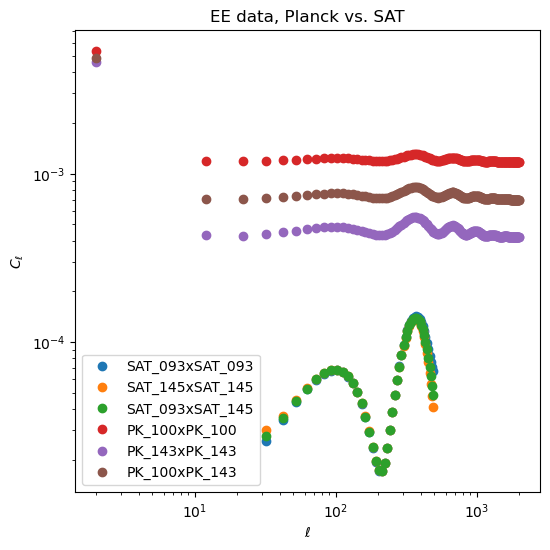

In [214]:
fig, ax = plt.subplots(1,1,figsize = (6,6))

for name in full_lik_data['data']['SAT']:
    curr_dict = full_lik_data['data']['SAT'][name]
    ax.loglog(curr_dict['ell'],curr_dict['c_ell'] , marker = 'o', label = name, linestyle = 'None')
    ax.legend()
for name in full_lik_data['data']['PK_pol']:
    curr_dict = full_lik_data['data']['PK_pol'][name]
    ax.loglog(curr_dict['ell'],curr_dict['c_ell'] , marker = 'o', label = name, linestyle = 'None')
    ax.set_title('EE data, Planck vs. SAT')
    ax.set_ylabel(r'$C_\ell$')
    ax.set_xlabel(r'$\ell$')
    ax.legend()

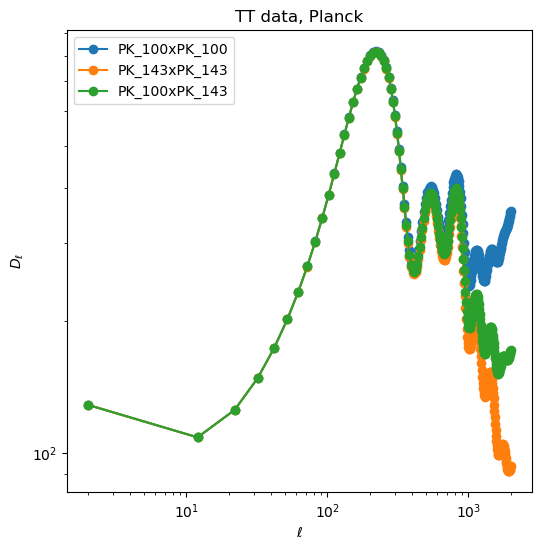

In [215]:
fig, ax = plt.subplots(1,1,figsize = (6,6))

for name in full_lik_data['data']['PK']:
    curr_dict = full_lik_data['data']['PK'][name]
    ell_plot = curr_dict['ell']
    pref = ell_plot*(ell_plot+1)/(2*np.pi)
    ax.loglog(ell_plot,pref*curr_dict['c_ell'] , marker = 'o', label = name)
    ax.set_title('TT data, Planck')
    ax.set_ylabel(r'$D_\ell$')
    ax.set_xlabel(r'$\ell$')
    ax.legend()

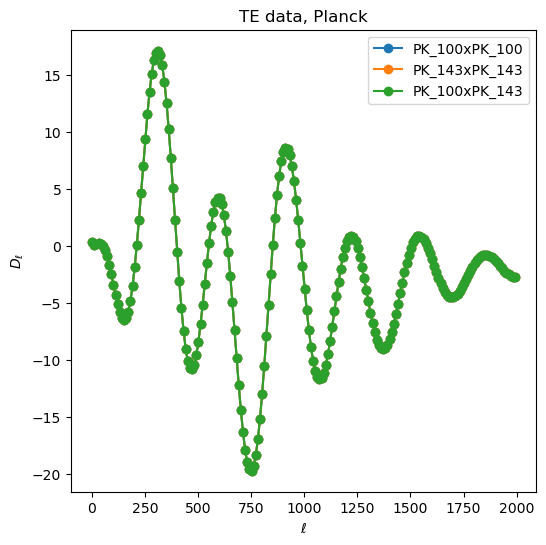

In [221]:
fig, ax = plt.subplots(1,1,figsize = (6,6))

for name in full_lik_data['data']['PK_cross']:
    curr_dict = full_lik_data['data']['PK_cross'][name]
    ell_plot = curr_dict['ell']
    pref = ell_plot*(ell_plot+1)/(2*np.pi)
    ax.plot(ell_plot,pref*curr_dict['c_ell'] , marker = 'o', label = name)
    ax.set_title('TE data, Planck')
    ax.set_ylabel(r'$D_\ell$')
    ax.set_xlabel(r'$\ell$')
    ax.legend()

In [225]:
def build_full_lik_cov(full_lik_data, setup, cases,
                       knox_auto_cov, knox_cross_cov):

    auto_blocks = {'SAT', 'LAT', 'LAT_pol', 'PK', 'PK_pol'}
    cross_block_map = {
        'LAT_cross': ('LAT', 'LAT_pol'),
        'PK_cross': ('PK', 'PK_pol'),
    }


    full_lik_cov = {'metadata': deepcopy(full_lik_data['metadata']),
                    'data':{}}

    for exp_key, spec_dict in full_lik_data['data'].items():
        dell_curr, fsky_curr = full_lik_data['metadata'][exp_key]['dell'],full_lik_data['metadata'][exp_key]['fsky']

        full_lik_cov['data'][exp_key] = {}

        if exp_key in auto_blocks:
            for spec_key, spec_info in spec_dict.items():
                c_ell = np.asarray(spec_info['c_ell'])
                ell = np.asarray(spec_info['ell'])

                cov = knox_auto_cov(
                    c_ell=c_ell,
                    ell=ell,
                    delta_ell=dell_curr,
                    fsky=fsky_curr
                )

                full_lik_cov['data'][exp_key][spec_key] = {
                    'cov': cov,
                    'ell': ell
                }


        elif exp_key in cross_block_map:
            tt_block, ee_block = cross_block_map[exp_key]

            if tt_block in full_lik_data['data'] and ee_block in full_lik_data['data']:
                for spec_key, spec_info in spec_dict.items():
                    if spec_key in full_lik_data['data'][tt_block] and spec_key in full_lik_data['data'][ee_block]:
                        c_cross = np.asarray(spec_info['c_ell'])
                        ell_cross = np.asarray(spec_info['ell'])

                        c_1 = np.asarray(full_lik_data['data'][tt_block][spec_key]['c_ell'])
                        c_2 = np.asarray(full_lik_data['data'][ee_block][spec_key]['c_ell'])

                        cov = knox_cross_cov(
                            c_cross=c_cross,
                            c_1=c_1,
                            c_2=c_2,
                            ell=ell_cross,
                            delta_ell=dell_curr,
                            fsky=fsky_curr
                        )

                        full_lik_cov['data'][exp_key][spec_key] = {
                            'cov': cov,
                            'ell': ell_cross
                        }

    return full_lik_cov

In [226]:
full_lik_cov = build_full_lik_cov(full_lik_data, setup, cases,knox_auto_cov, knox_cross_cov)

In [228]:
full_lik_cov

{'metadata': {'SAT': {'yrs': 1.0,
   'sens_mode': 1,
   'f_mode': 0,
   'fsky': 0.1,
   'lmax': 500,
   'dell': 10,
   'cuts': [30, 500],
   'cell_type': 'EE'},
  'PK': {'lmax': 2000,
   'dell': 10,
   'fsky': 1.0,
   'cuts': [2, 2000],
   'cell_type': 'TT'},
  'PK_pol': {'lmax': 2000,
   'dell': 10,
   'fsky': 1.0,
   'cuts': [2, 2000],
   'cell_type': 'EE'},
  'PK_cross': {'lmax': 2000,
   'dell': 10,
   'fsky': 1.0,
   'cuts': [2, 2000],
   'cell_type': 'TE'}},
 'data': {'SAT': {'SAT_093xSAT_093': {'cov': array([2.07110950e-11, 2.79780350e-11, 3.65270730e-11, 4.39971967e-11,
           4.90001967e-11, 5.07933387e-11, 4.93356662e-11, 4.50989913e-11,
           3.88906434e-11, 3.16714673e-11, 2.43568858e-11, 1.76844828e-11,
           1.21283082e-11, 7.88670716e-12, 4.92119635e-12, 3.03533728e-12,
           1.96319298e-12, 1.46348508e-12, 1.37424542e-12, 1.66075726e-12,
           2.39306351e-12, 3.73643408e-12, 5.88504700e-12, 8.99140269e-12,
           1.31417402e-11, 1.82894341e-1

### Recreating Fig. 12 of ACT DR6 Spectra Paper

Text(0.5, 1.0, 'EE errors')

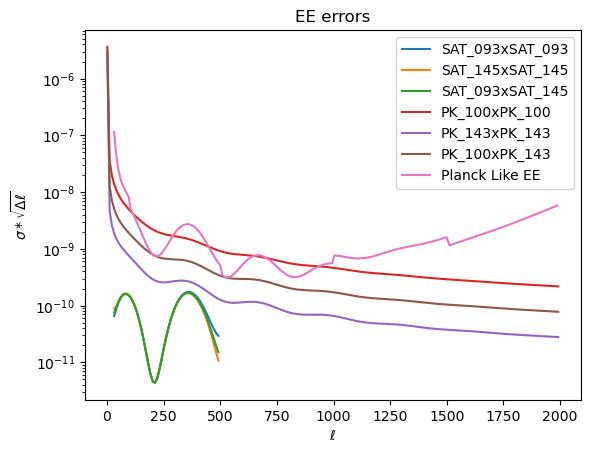

In [264]:
### EE Spectra Comparison

exp_key = 'SAT'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    plt.plot(ell_plot,diag_plot*np.sqrt(dell), label = k)
    plt.yscale('log')


exp_key = 'PK_pol'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    plt.plot(ell_plot,diag_plot*np.sqrt(dell), label = k)
    plt.yscale('log')

cell_type = 'EE'
ell_plot = lite_data[cell_type]['ell']
diag_plot = lite_data[cell_type]['err']
dell = lite_data[cell_type]['b_ell']
plt.plot(ell_plot,diag_plot*np.sqrt(dell), label = 'Planck Like {}'.format(cell_type))
plt.yscale('log')

plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r'$\sigma * \sqrt{\Delta \ell}$')
plt.title("{} errors".format(cell_type))


Text(0.5, 1.0, 'TT errors')

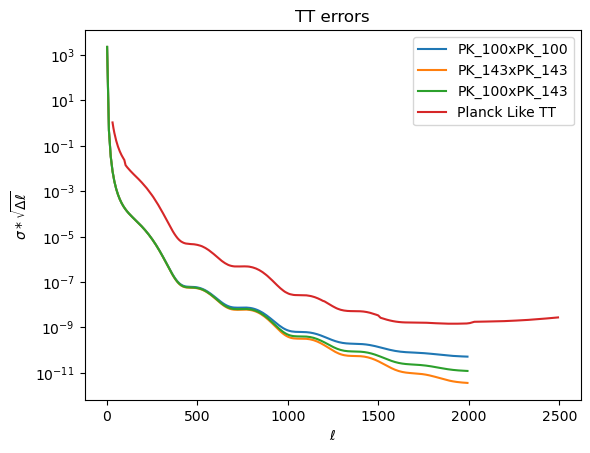

In [265]:
### TT Spectra Comparison

exp_key = 'PK'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    plt.plot(ell_plot,diag_plot*np.sqrt(dell), label = k)
    plt.yscale('log')

cell_type = 'TT'
ell_plot = lite_data[cell_type]['ell']
diag_plot = lite_data[cell_type]['err']
dell = lite_data[cell_type]['b_ell']
plt.plot(ell_plot,diag_plot*np.sqrt(dell), label = 'Planck Like {}'.format(cell_type))
plt.yscale('log')

plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r'$\sigma * \sqrt{\Delta \ell}$')
plt.title("{} errors".format(cell_type))


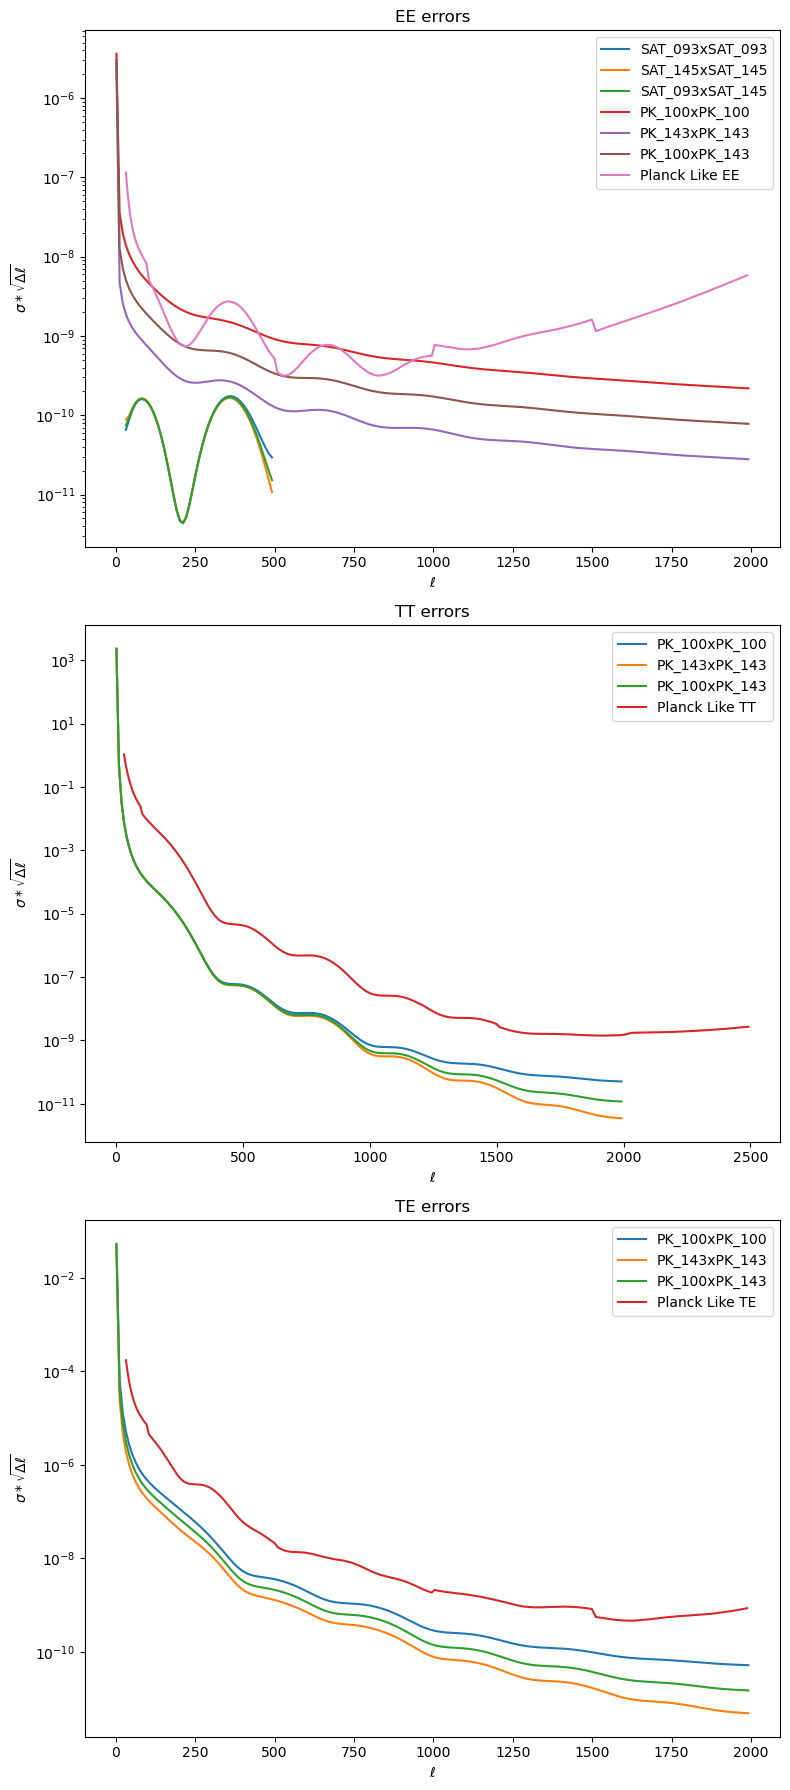

In [268]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

### EE Spectra Comparison

ax = axes[0]

exp_key = 'SAT'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    ax.plot(ell_plot, diag_plot*np.sqrt(dell), label=k)
    ax.set_yscale('log')

exp_key = 'PK_pol'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    ax.plot(ell_plot, diag_plot*np.sqrt(dell), label=k)
    ax.set_yscale('log')

cell_type = 'EE'
ell_plot = lite_data[cell_type]['ell']
diag_plot = lite_data[cell_type]['err']
dell = lite_data[cell_type]['b_ell']
ax.plot(ell_plot, diag_plot*np.sqrt(dell), 
        label='Planck Like {}'.format(cell_type))
ax.set_yscale('log')

ax.legend()
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r'$\sigma * \sqrt{\Delta \ell}$')
ax.set_title("{} errors".format(cell_type))


### TT Spectra Comparison
ax = axes[1]

exp_key = 'PK'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    ax.plot(ell_plot, diag_plot*np.sqrt(dell), label=k)
    ax.set_yscale('log')

cell_type = 'TT'
ell_plot = lite_data[cell_type]['ell']
diag_plot = lite_data[cell_type]['err']
dell = lite_data[cell_type]['b_ell']
ax.plot(ell_plot, diag_plot*np.sqrt(dell), 
        label='Planck Like {}'.format(cell_type))
ax.set_yscale('log')

ax.legend()
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r'$\sigma * \sqrt{\Delta \ell}$')
ax.set_title("{} errors".format(cell_type))


### TE Spectra Comparison 

ax = axes[2]

exp_key = 'PK_cross'
for k in full_lik_cov['data'][exp_key].keys():
    ell_plot = full_lik_cov['data'][exp_key][k]['ell']
    diag_plot = full_lik_cov['data'][exp_key][k]['cov']
    dell = full_lik_cov['metadata'][exp_key]['dell']
    ax.plot(ell_plot, diag_plot*np.sqrt(dell), label=k)
    ax.set_yscale('log')

cell_type = 'TE'
ell_plot = lite_data[cell_type]['ell']
diag_plot = lite_data[cell_type]['err']
dell = lite_data[cell_type]['b_ell']
ax.plot(ell_plot, diag_plot*np.sqrt(dell), 
        label='Planck Like {}'.format(cell_type))
ax.set_yscale('log')

ax.legend()
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r'$\sigma * \sqrt{\Delta \ell}$')
ax.set_title("{} errors".format(cell_type))


plt.tight_layout()
plt.savefig('planck_err_comp.png', dpi=300, bbox_inches='tight')
plt.show()

### game time for Fisher !

In [158]:
### so, right now I am running with Susanna's choice of parameters. In the near future, I will do a convergence study, and optimize for it.

### rationale for Fisher:
- func takes in full_lik_cov + specification of which exp_key (= experiment key) I want in the covariance
      - smaller func makes the cov by just stringing things together (make np.diag and stack if length of element in cov_ask = 3, which indicates TT, TE EE covariance, and cov is stacked as [[TT,TE],[TE,EE]], where each denotes a diagonal matrix; if only one experiment is requested, then just put all the spectra in one array and do np.diag.)
  
- find the type in the metadata (full_lik_data['metadata'][exp_key]['cell_type']; options: 'TT','TE', 'EE')

- make dcls (use central diff, then stack just like cov)

- run the fisher algo, which is just an implementation of:
          $F_{ij} = \sum_ell (2\ell+1)*fsky*Tr(C_\ell^-1 \frac{\partial C}{\partial \theta_i}C_\ell^-1 \frac{\partial C}{\partial \theta_j})

In [275]:
import numpy as np

SCALED10_PARAMS = {"P_RR_1", "P_RR_2", "P_II_1", "P_II_2"}

param_list = [
    "omega_b", "omega_cdm", "h", "tau_reio",
    "P_RR_1", "P_RR_2", "P_II_1", "P_II_2"
]

steps_abs = {
    "omega_b": 2.5e-5,
    "omega_cdm": 1.5e-4,
    "h": 6.0e-4,
    "tau_reio": 6.0e-5,
}

steps_scaled10 = {
    "P_RR_1": 0.01,
    "P_RR_2": 0.01,
    "P_II_1": 0.05,
    "P_II_2": 0.05,
}

theta0 = {
    "omega_b": 0.02237,
    "omega_cdm": 0.11933,
    "h": 0.6766,
    "tau_reio": 0.0561,
    "P_RR_1": 2.3e-9,
    "P_RR_2": 2.3e-9,
    "P_II_1": 1.0e-11,
    "P_II_2": 1.0e-11,
}

def get_fisher_value(theta, p):
    return 1e10 * theta[p] if p in SCALED10_PARAMS else theta[p]

def set_from_fisher_value(theta, p, x):
    th = dict(theta)
    th[p] = x * 1e-10 if p in SCALED10_PARAMS else x
    return th

def _channel_items_in_order(full_lik_cov, exp_key):
    return list(full_lik_cov["data"][exp_key].items())

def _cut_mask(full_lik_cov, exp_key, ell):
    lmin, lmax = full_lik_cov["metadata"][exp_key]["cuts"]
    return (ell >= lmin) & (ell <= lmax)

def _project_one_exp_to_blocks(raw_cls, full_lik_cov, exp_key):
    spec = full_lik_cov["metadata"][exp_key]["cell_type"]
    fsky = full_lik_cov["metadata"][exp_key]["fsky"]

    ell_all = []
    val_all = []
    w_all = []

    for _, ch_dict in _channel_items_in_order(full_lik_cov, exp_key):
        ell = np.asarray(ch_dict["ell"], dtype=int)
        mask = _cut_mask(full_lik_cov, exp_key, ell)
        ell_use = ell[mask]
        vals = np.asarray(raw_cls[spec])[ell_use]

        ell_all.append(ell_use)
        val_all.append(vals)
        w_all.append((2.0 * ell_use + 1.0) * fsky)

    ell_all = np.concatenate(ell_all)
    val_all = np.concatenate(val_all)
    w_all = np.concatenate(w_all)

    C_blocks = np.zeros((len(val_all), 1, 1), dtype=float)
    C_blocks[:, 0, 0] = val_all
    return ell_all, C_blocks, w_all

def _project_triplet_to_blocks(raw_cls, full_lik_cov, exp_keys):
    by_type = {full_lik_cov["metadata"][k]["cell_type"]: k for k in exp_keys}

    kTT = by_type["TT"]
    kTE = by_type["TE"]
    kEE = by_type["EE"]
    fsky = full_lik_cov["metadata"][kTT]["fsky"]

    tt_items = _channel_items_in_order(full_lik_cov, kTT)
    te_items = _channel_items_in_order(full_lik_cov, kTE)
    ee_items = _channel_items_in_order(full_lik_cov, kEE)

    tt_cls = np.asarray(raw_cls["TT"])
    te_cls = np.asarray(raw_cls["TE"])
    ee_cls = np.asarray(raw_cls["EE"])

    ell_all = []
    C_list = []
    w_all = []

    for (_, tt_dict), (_, te_dict), (_, ee_dict) in zip(tt_items, te_items, ee_items):
        ell = np.asarray(tt_dict["ell"], dtype=int)
        mask = _cut_mask(full_lik_cov, kTT, ell)
        ell_use = ell[mask]

        C_here = np.zeros((len(ell_use), 2, 2), dtype=float)
        C_here[:, 0, 0] = tt_cls[ell_use]
        C_here[:, 0, 1] = te_cls[ell_use]
        C_here[:, 1, 0] = te_cls[ell_use]
        C_here[:, 1, 1] = ee_cls[ell_use]

        ell_all.append(ell_use)
        C_list.append(C_here)
        w_all.append((2.0 * ell_use + 1.0) * fsky)

    ell_all = np.concatenate(ell_all)
    C_blocks = np.concatenate(C_list, axis=0)
    w_all = np.concatenate(w_all)
    return ell_all, C_blocks, w_all

def build_theory_blocks(theta, full_lik_cov, exp_keys, compute_cls, ell_max=10000):
    raw_cls = compute_cls(**theta, lmax=ell_max)
    if isinstance(exp_keys, str):
        exp_keys = [exp_keys]
    if len(exp_keys) == 1:
        return _project_one_exp_to_blocks(raw_cls, full_lik_cov, exp_keys[0])
    return _project_triplet_to_blocks(raw_cls, full_lik_cov, exp_keys)

def build_cov_blocks(full_lik_cov, exp_keys):
    if isinstance(exp_keys, str):
        exp_keys = [exp_keys]

    if len(exp_keys) == 1:
        exp_key = exp_keys[0]
        fsky = full_lik_cov["metadata"][exp_key]["fsky"]

        ell_all = []
        vals_all = []
        w_all = []

        for _, ch_dict in _channel_items_in_order(full_lik_cov, exp_key):
            ell = np.asarray(ch_dict["ell"], dtype=int)
            cov = np.asarray(ch_dict["cov"], dtype=float)
            mask = _cut_mask(full_lik_cov, exp_key, ell)

            ell_use = ell[mask]
            cov_use = cov[mask]

            ell_all.append(ell_use)
            vals_all.append(cov_use)
            w_all.append((2.0 * ell_use + 1.0) * fsky)

        ell_all = np.concatenate(ell_all)
        vals_all = np.concatenate(vals_all)
        w_all = np.concatenate(w_all)

        C_blocks = np.zeros((len(vals_all), 1, 1), dtype=float)
        C_blocks[:, 0, 0] = vals_all
        return ell_all, C_blocks, w_all

    by_type = {full_lik_cov["metadata"][k]["cell_type"]: k for k in exp_keys}

    kTT = by_type["TT"]
    kTE = by_type["TE"]
    kEE = by_type["EE"]
    fsky = full_lik_cov["metadata"][kTT]["fsky"]

    tt_items = _channel_items_in_order(full_lik_cov, kTT)
    te_items = _channel_items_in_order(full_lik_cov, kTE)
    ee_items = _channel_items_in_order(full_lik_cov, kEE)

    ell_all = []
    C_list = []
    w_all = []

    for (_, tt_dict), (_, te_dict), (_, ee_dict) in zip(tt_items, te_items, ee_items):
        ell = np.asarray(tt_dict["ell"], dtype=int)
        mask = _cut_mask(full_lik_cov, kTT, ell)

        tt_cov = np.asarray(tt_dict["cov"], dtype=float)[mask]
        te_cov = np.asarray(te_dict["cov"], dtype=float)[mask]
        ee_cov = np.asarray(ee_dict["cov"], dtype=float)[mask]
        ell_use = ell[mask]

        C_here = np.zeros((len(ell_use), 2, 2), dtype=float)
        C_here[:, 0, 0] = tt_cov
        C_here[:, 0, 1] = te_cov
        C_here[:, 1, 0] = te_cov
        C_here[:, 1, 1] = ee_cov

        ell_all.append(ell_use)
        C_list.append(C_here)
        w_all.append((2.0 * ell_use + 1.0) * fsky)

    ell_all = np.concatenate(ell_all)
    C_blocks = np.concatenate(C_list, axis=0)
    w_all = np.concatenate(w_all)
    return ell_all, C_blocks, w_all

def central_diff_blocks(theta0, p, step, build_blocks_fn, fisher_scaled=False):
    if fisher_scaled:
        x0 = get_fisher_value(theta0, p)
        hi = set_from_fisher_value(theta0, p, x0 + step)
        lo = set_from_fisher_value(theta0, p, x0 - step)
    else:
        hi = dict(theta0)
        lo = dict(theta0)
        hi[p] = theta0[p] + step
        lo[p] = theta0[p] - step

    ell_hi, C_hi, w_hi = build_blocks_fn(hi)
    ell_lo, C_lo, w_lo = build_blocks_fn(lo)

    return ell_hi, (C_hi - C_lo) / (2.0 * step), w_hi

def fisher_analysis_trace(
    theta0,
    param_list,
    full_lik_cov,
    exp_keys,
    compute_cls,
    steps_abs,
    steps_scaled10,
    ell_max=10000,
    use_pinv=False,
):
    ell_cov, Cov_blocks, weights = build_cov_blocks(full_lik_cov, exp_keys)

    invCov = np.zeros_like(Cov_blocks)
    for a in range(Cov_blocks.shape[0]):
        invCov[a] = np.linalg.pinv(Cov_blocks[a]) if use_pinv else np.linalg.inv(Cov_blocks[a])

    def build_blocks(th):
        return build_theory_blocks(
            th,
            full_lik_cov=full_lik_cov,
            exp_keys=exp_keys,
            compute_cls=compute_cls,
            ell_max=ell_max,
        )

    dC = []
    for p in param_list:
        if p in steps_abs:
            _, dC_p, _ = central_diff_blocks(theta0, p, steps_abs[p], build_blocks, fisher_scaled=False)
        else:
            _, dC_p, _ = central_diff_blocks(theta0, p, steps_scaled10[p], build_blocks, fisher_scaled=True)
        dC.append(dC_p)

    npar = len(param_list)
    F = np.zeros((npar, npar), dtype=float)

    for i in range(npar):
        for j in range(i, npar):
            s = 0.0
            for a in range(len(weights)):
                s += weights[a] * np.trace(invCov[a] @ dC[i][a] @ invCov[a] @ dC[j][a])
            F[i, j] = s
            F[j, i] = s

    return F, dC, ell_cov, Cov_blocks


F_planck, dC_planck, ell_planck, Cov_planck = fisher_analysis_trace(
    theta0=theta0,
    param_list=param_list,
    full_lik_cov=full_lik_cov,
    exp_keys=["PK", "PK_cross", "PK_pol"],
    compute_cls=compute_cls,
    steps_abs=steps_abs,
    steps_scaled10=steps_scaled10,
    ell_max=10000,
    use_pinv=False,
)

Cov_params = np.linalg.pinv(F_planck)

,Fiducial,sigma,S/N
omega_b,0.02237,1.433910e-11,1.560070e+09
omega_cdm,0.11933,1.188997e-10,1.003619e+09
h,0.67660,5.226127e-10,1.294649e+09
tau_reio,0.05610,1.484844e-09,3.778175e+07
P_RR_1,23.00000,1.042158e-07,2.206959e+08
P_RR_2,23.00000,6.946188e-08,3.311169e+08
P_II_1,0.10000,4.280603e-06,2.336119e+04
P_II_2,0.10000,2.281406e-06,4.383262e+04


,omega_b,omega_cdm,h,tau_reio,P_RR_1,P_RR_2,P_II_1,P_II_2
omega_b,1.000000,-0.422612,0.608980,0.360045,0.516368,0.349226,-0.083298,0.063731
omega_cdm,-0.422612,1.000000,-0.973059,-0.684451,-0.470180,-0.660861,-0.164163,0.239134
h,0.608980,-0.973059,1.000000,0.685320,0.539994,0.664197,0.137243,-0.208161
tau_reio,0.360045,-0.684451,0.685320,1.000000,0.854640,0.995270,-0.140798,-0.408734
P_RR_1,0.516368,-0.470180,0.539994,0.854640,1.000000,0.889447,0.015992,-0.580478
P_RR_2,0.349226,-0.660861,0.664197,0.995270,0.889447,1.000000,-0.082383,-0.486487
P_II_1,-0.083298,-0.164163,0.137243,-0.140798,0.015992,-0.082383,1.000000,-0.664801
P_II_2,0.063731,0.239134,-0.208161,-0.408734,-0.580478,-0.486487,-0.664801,1.000000


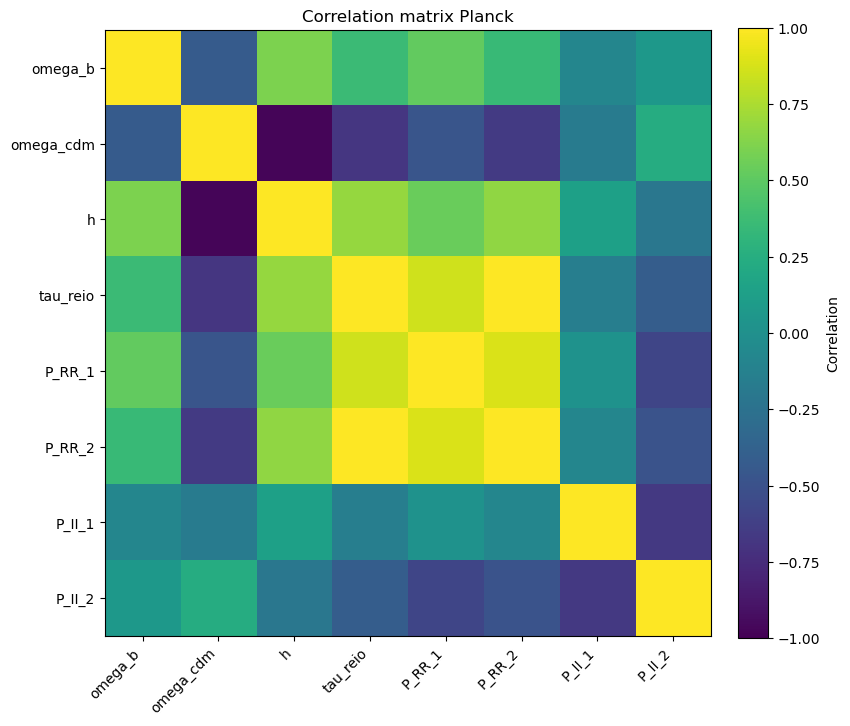

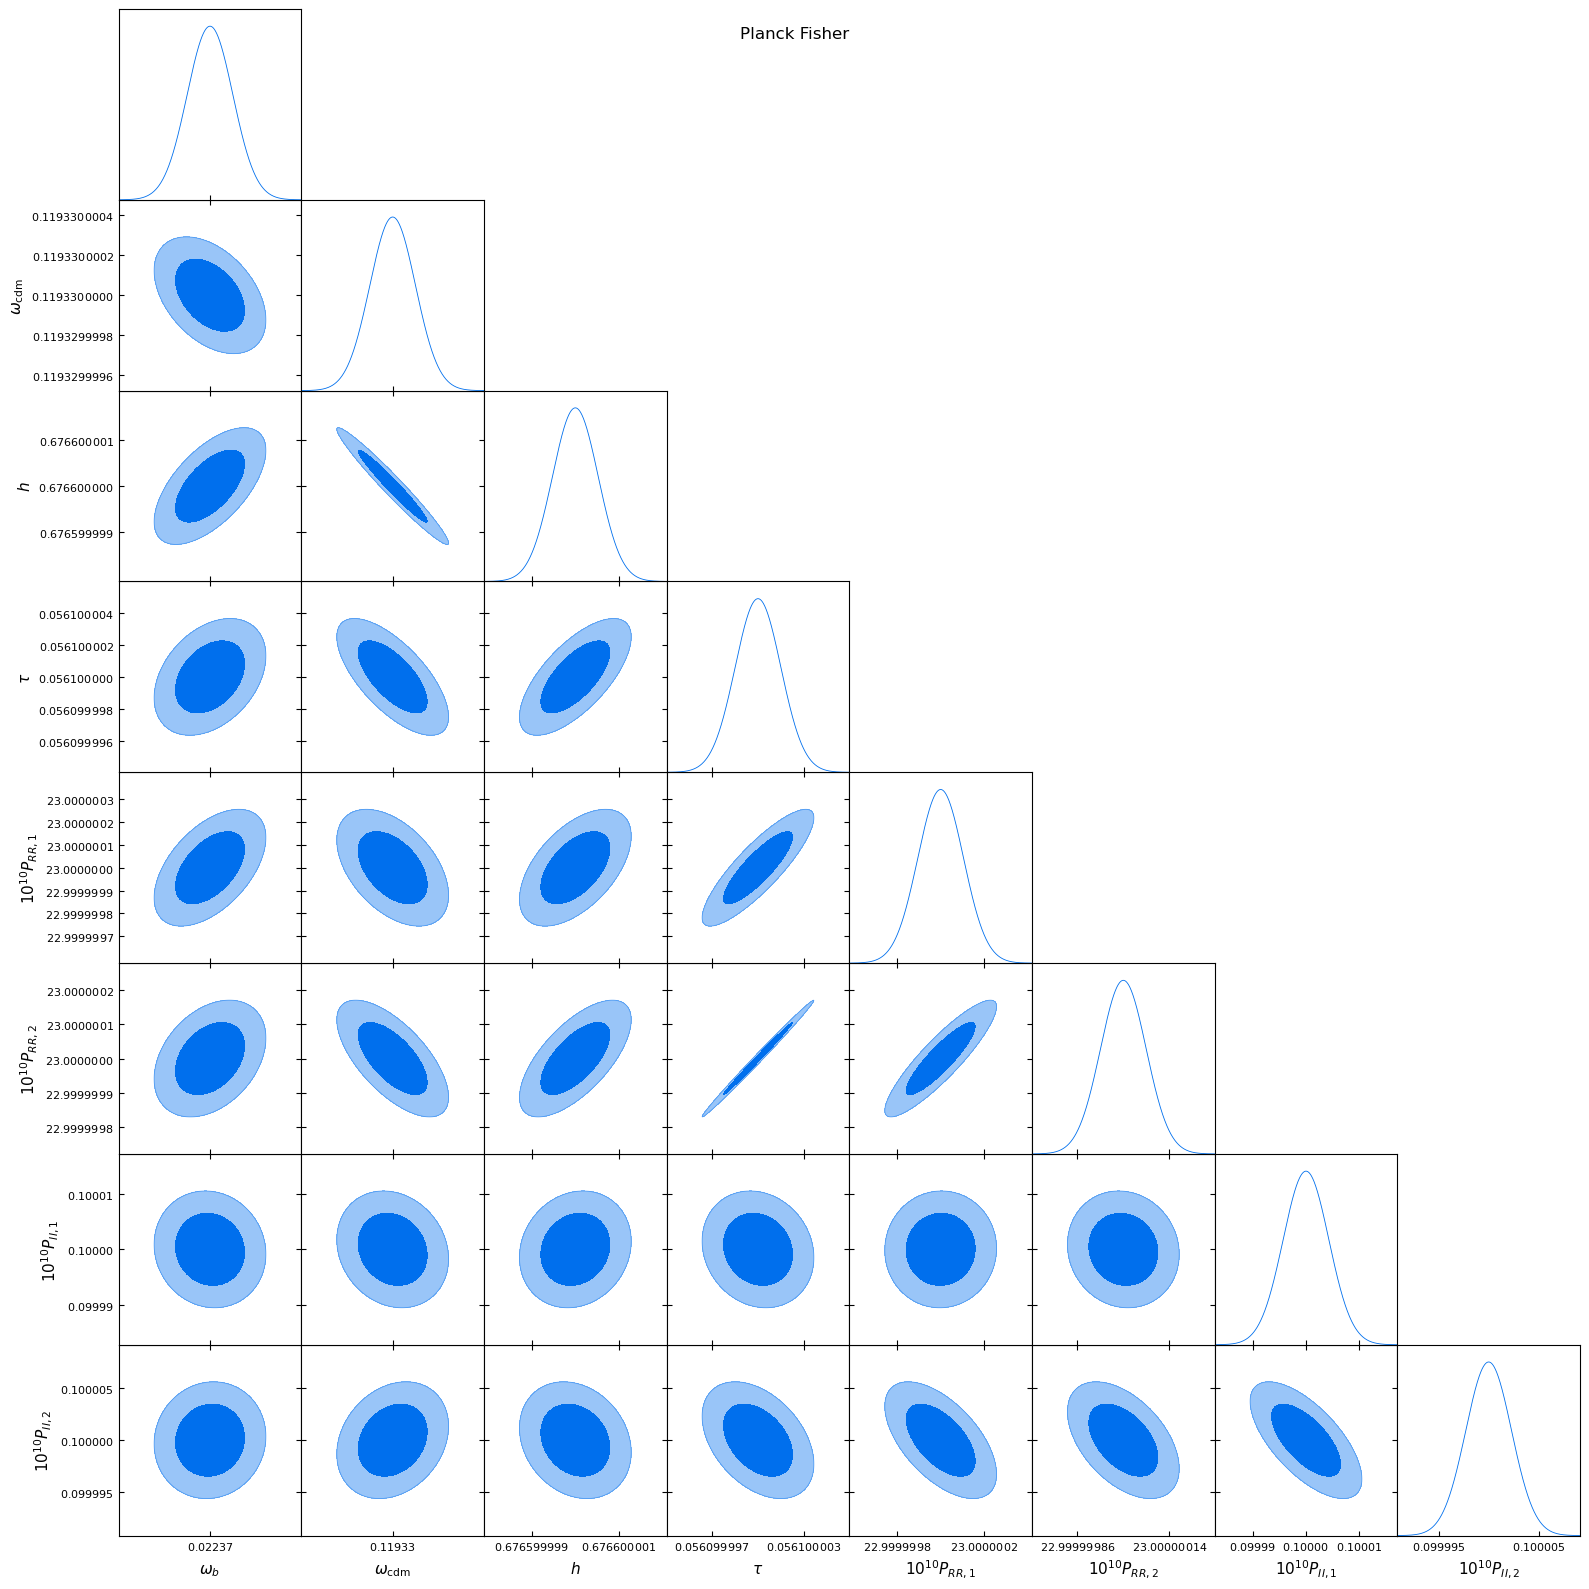

In [276]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from getdist.gaussian_mixtures import GaussianND
from getdist import plots

EXP_NAME = 'Planck'

scaled10_params = {"P_RR_1", "P_RR_2", "P_II_1", "P_II_2"}

def fisher_center(theta0, p):
    return 1e10 * theta0[p] if p in scaled10_params else theta0[p]

Cov_params = np.linalg.pinv(F_planck)

centers = np.array([fisher_center(theta0, p) for p in param_list], dtype=float)
sigmas = np.sqrt(np.diag(Cov_params))

df = pd.DataFrame(
    {
        "Fiducial": centers,
        "sigma": sigmas,
        "S/N": np.divide(centers, sigmas, out=np.full_like(centers, np.nan), where=sigmas > 0),
    },
    index=param_list,
)
display(df)

den = np.outer(sigmas, sigmas)
Corr = np.divide(Cov_params, den, out=np.zeros_like(Cov_params), where=den > 0)
np.fill_diagonal(Corr, 1.0)

corr_df = pd.DataFrame(Corr, index=param_list, columns=param_list)
display(corr_df)

fig, ax = plt.subplots(figsize=(0.7 * len(param_list) + 3, 0.7 * len(param_list) + 3))
im = ax.imshow(Corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(param_list)))
ax.set_yticks(range(len(param_list)))
ax.set_xticklabels(param_list, rotation=45, ha="right")
ax.set_yticklabels(param_list)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlation")
ax.set_title("Correlation matrix {}".format(EXP_NAME))
plt.tight_layout()
plt.savefig("corr_matrix_{}".format(EXP_NAME))
plt.show()

latex_label_map = {
    "omega_b":   r"\omega_b",
    "omega_cdm": r"\omega_{\rm cdm}",
    "h":         r"h",
    "tau_reio":  r"\tau",
    "P_RR_1":    r"10^{10}P_{RR,1}",
    "P_RR_2":    r"10^{10}P_{RR,2}",
    "P_II_1":    r"10^{10}P_{II,1}",
    "P_II_2":    r"10^{10}P_{II,2}",
}

latex_labels = [latex_label_map[p] for p in param_list]

gauss = GaussianND(
    centers,
    Cov_params,
    names=param_list,
    labels=latex_labels,
)

g = plots.get_subplot_plotter()
g.triangle_plot([gauss], param_list, filled=True)
plt.suptitle("{} Fisher".format(EXP_NAME))
plt.savefig("triangle_plot_{}".format(EXP_NAME))
plt.show()

fig, ax = plt.subplots(figsize=(8, 0.6 * len(df) + 1))
ax.axis("off")

table = ax.table(
    cellText=np.round(df.values, 4),
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.tight_layout()
plt.savefig("fisher_summary_{}.png".format(EXP_NAME), dpi=300, bbox_inches="tight")
plt.close(fig)